# Sprint 8 - Proyecto

## 1. Análisis exploratorio de datos (Python)

Para estos dos datasets ahora necesitas:

In [40]:
#Importado de las librerias necesarias para el proyecto

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as st
from scipy.stats import shapiro, levene
from scipy.stats import mannwhitneyu

### 1.1 - importar los archivos

In [3]:
#Importar los CSV a DF
company_trips = pd.read_csv('datasets/moved_project_sql_result_01.csv')
chicago_dropoffs = pd.read_csv('datasets/moved_project_sql_result_04.csv')
loop_trips = pd.read_csv('datasets/moved_project_sql_result_07.csv')

### 1.2 - estudiar los datos que contienen

In [4]:
#Analisis del dataset company_trips
company_trips.info()
display(company_trips.describe())
display(company_trips.sample(5))
print('Datos duplicados del DF:',company_trips.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB


,trips_amount
count,64.000000
mean,2145.484375
std,3812.310186
min,2.000000
25%,20.750000
50%,178.500000
75%,2106.500000
max,19558.000000


,company_name,trips_amount
57,Metro Group,11
45,3011 - 66308 JBL Cab Inc.,25
13,Nova Taxi Affiliation Llc,3175
14,Patriot Taxi Dba Peace Taxi Associat,2235
11,Globe Taxi,4383


Datos duplicados del DF: 0


In [5]:
#Analisis del dataset chicago_dropoffs
chicago_dropoffs.info()
display(chicago_dropoffs.describe())
display(chicago_dropoffs.sample(5))
print('Datos duplicados del DF:',chicago_dropoffs.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB


,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667


,dropoff_location_name,average_trips
35,Norwood Park,95.233333
79,Fuller Park,8.166667
43,Mckinley Park,64.033333
80,West Lawn,7.733333
39,Jefferson Park,74.333333


Datos duplicados del DF: 0


In [6]:
#Analisis del dataset loop_trips al aeropuerto O'Hare
loop_trips.info()
display(loop_trips.describe())
display(loop_trips.sample(5))
print('Datos duplicados del DF:',loop_trips.duplicated().sum())
loop_trips[loop_trips.duplicated()]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB


,duration_seconds
count,1068.000000
mean,2071.731273
std,769.461125
min,0.000000
25%,1438.250000
50%,1980.000000
75%,2580.000000
max,7440.000000


,start_ts,weather_conditions,duration_seconds
182,2017-11-11 11:00:00,Good,2054.0
423,2017-11-11 08:00:00,Good,1440.0
7,2017-11-18 11:00:00,Good,2280.0
875,2017-11-11 23:00:00,Good,1416.0
959,2017-11-11 07:00:00,Good,1260.0


Datos duplicados del DF: 197


,start_ts,weather_conditions,duration_seconds
62,2017-11-11 06:00:00,Good,1260.0
74,2017-11-11 08:00:00,Good,1380.0
76,2017-11-04 09:00:00,Good,1380.0
117,2017-11-11 07:00:00,Good,1380.0
119,2017-11-04 14:00:00,Good,3300.0
...,...,...,...
1054,2017-11-11 07:00:00,Good,1380.0
1058,2017-11-25 12:00:00,Good,1440.0
1062,2017-11-11 06:00:00,Good,1500.0
1065,2017-11-11 13:00:00,Good,2100.0


    - Podemos observar que todos los datasets parecieran no tener problemas de datos nulos y a pesar de que el DF LOOP_TRIPS sí contine datos duplicados no podemos confirmar que no sean una casualidad por lo que mantendremos todos los datos.
    - Al revisar todas las series de los DF el único que puede ser modificado sin alterar su naturaleza es LOOP_TRIPS en su serie START_TS que de ser object lo modificaremos a tipo date

### 1.3 - asegurarte de que los tipos de datos sean correctos

In [7]:
#Modificamos la serie de START_TS para que sea un datetime
loop_trips['start_ts'] = pd.to_datetime(loop_trips['start_ts'])
display(loop_trips.head(3))
loop_trips.info()

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   start_ts            1068 non-null   datetime64[ns]
 1   weather_conditions  1068 non-null   object        
 2   duration_seconds    1068 non-null   float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 25.2+ KB


### 1.4 - identificar los 10 principales barrios en términos de finalización del recorrido

In [8]:
#Ordenamos el DF CHICAGO_DROPOFFS por la columna average_trips para conocer que barrios tienen mayor cantidad de viajes en promedio
top_dropoffs= chicago_dropoffs.sort_values(by= 'average_trips',ascending=False).head(10)
top_dropoffs

,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667


### 1.5 - hacer gráficos: 
#### 1.5.1 - empresas de taxis y número de viajes


/tmp/ipykernel_117389/2258387450.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_companies, x='company_name', y='trips_amount', palette='viridis')


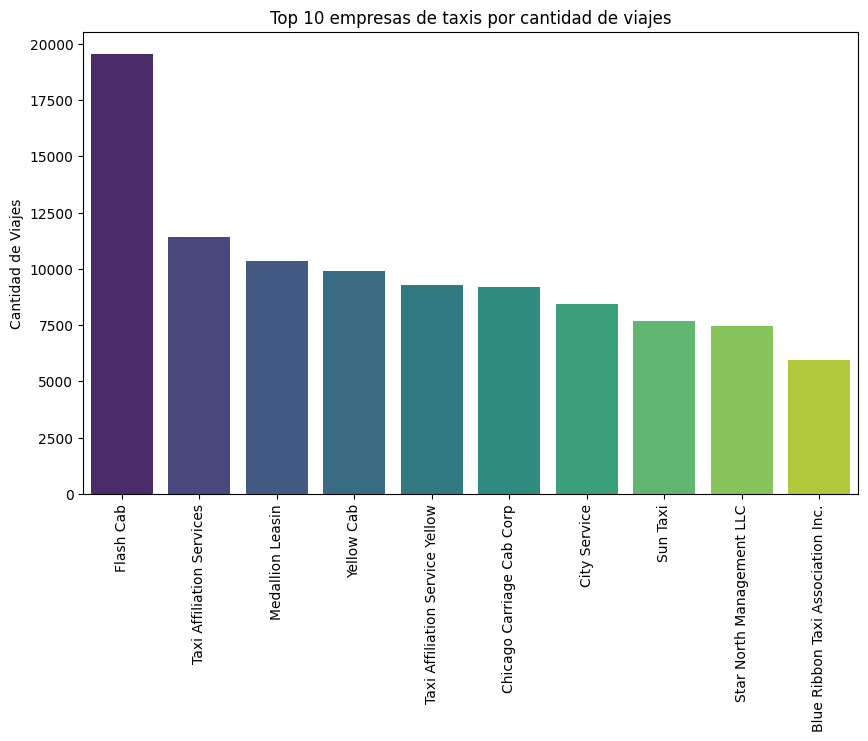

In [ ]:
#Generamos una grafica de barras para visualizar las empresas de taxis y sus números de viajes
#Antes construimos un nuevo DF con las columnas que nos interesan
top_companies = company_trips.sort_values(by='trips_amount',ascending=False).head(10)
#Generamos la grafica
plt.figure(figsize=(10,6))
sns.barplot(data=top_companies, x='company_name', y='trips_amount', palette='viridis')
plt.title('Top 10 empresas de taxis por cantidad de viajes')
plt.xlabel(None)
plt.ylabel('Cantidad de Viajes')
plt.xticks(rotation=90)
plt.show()

#### 1.5.2 - los 10 barrios principales por número de finalizaciones

/tmp/ipykernel_117389/2211652566.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_dropoffs, x='dropoff_location_name', y='average_trips', palette='viridis')


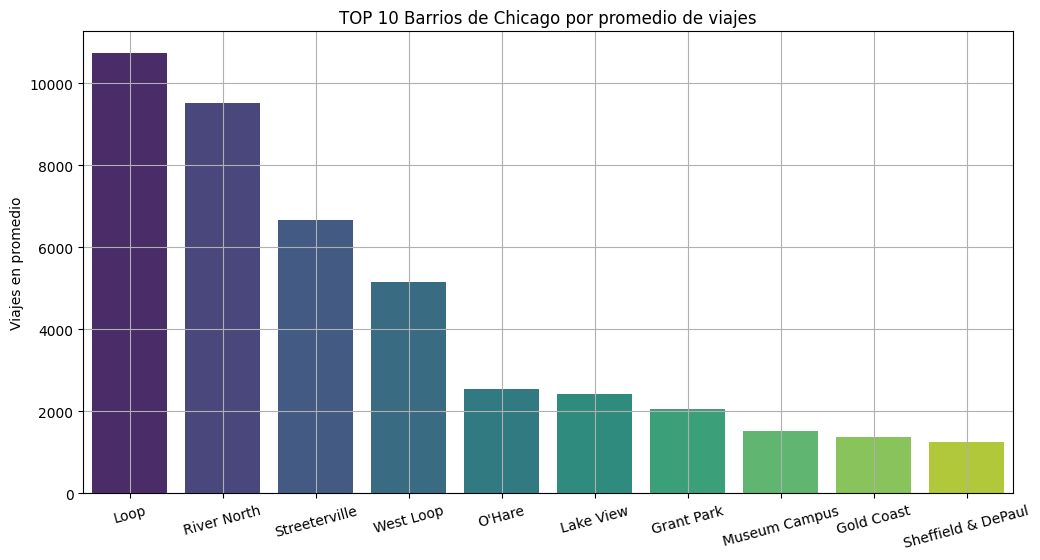

In [10]:
#Generamos una gráfica de barras para visualizar los 10 barrios con mayor promedio de viajes
plt.figure(figsize=(12, 6))
sns.barplot(data=top_dropoffs, x='dropoff_location_name', y='average_trips', palette='viridis')
plt.title('TOP 10 Barrios de Chicago por promedio de viajes')
plt.ylabel('Viajes en promedio')  
plt.xlabel(None)
plt.xticks(rotation=15)
plt.grid(True)
plt.show()

### 1.6 - sacar conclusiones basadas en cada gráfico y explicar los resultados

    - En la gráfica de "TOP 10 empresas de taxis por cantidad de viajes" identificamos rapidamente la superioridad de la empresa FLASH CAB que cuenta con practicamente el doble de viajes que su competidor más cercano, del segundo lugar en adelante parece que existir una diferencia aproximada del 10% en tendencia entre el resto de competidores.
    - Continuando con la gráfica de "TOP 10 Barrios de Chicago por promedio de viajes" notamos que los primeros 4 barrios son los que se llevan la mayor parte de la distribución, después de investigar un poco encontramos que estos barrios forman parte de los barrios más ricos de la Chicago por lo que ahora tenemos una idea del porque estan en el top 4.

# 2. Prueba la hipótesis:

"La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos".

Decide por tu cuenta dónde establecer el nivel de significación (alfa).

Explica:

### 2.1 cómo planteaste las hipótesis nula y alternativa

H0 - NO HAY DIRENCIA SIGINIFICATIVA en la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare los días sábados con condición lluviosa.

H1 - SI HAY DIRENCIA SIGINIFICATIVA en la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare los días sábados con condición lluviosa.

    - Crearemos 2 DF el primero llamado RAINY_SATURDAYS y el segundo GOOD_SATURDAYS, en el primero filtraremos el DF LOOP_TRIPS por la serie WEATHER CONDITIONS "Bad" o "Good" respectivamente, y luego por el día de la semana para obtener solo los sabados.

In [18]:
#Generamos un nuevo DF de loop_trips filtrados por la serie START_TS donde se obtendra solo el día sabado y la serie WEATHER_CONDITIONS donde aparezca la condición del clima el string "Bad"
#Para filtrar primero por WEATHER_CONDITIONS es necesario recordar que con anterioridad esta serie de la base de datos fue llenada por 2 condiciones: 
#"Bad" cuando la descripción del clima conenia la palabra "rain" o "storm" y "Good" en caso contrario.
rainy_saturdays = loop_trips[loop_trips['weather_conditions'].str.contains('Bad', na=False)]

#Ahora filtramos por la serie START_TS para que solo contenga los días sabados
#Utilizamos dt.dayofweek para obtener el día de la semana, donde 0 es lunes y 6 es domingo, por lo tanto, 5 es sábado
rainy_saturdays = rainy_saturdays[rainy_saturdays['start_ts'].dt.dayofweek == 5].reset_index(drop=True)
rainy_saturdays

,start_ts,weather_conditions,duration_seconds
0,2017-11-04 16:00:00,Bad,2969.0
1,2017-11-18 12:00:00,Bad,1980.0
2,2017-11-04 17:00:00,Bad,2460.0
3,2017-11-04 16:00:00,Bad,2760.0
4,2017-11-18 12:00:00,Bad,2460.0
...,...,...,...
175,2017-11-18 12:00:00,Bad,2560.0
176,2017-11-18 10:00:00,Bad,1908.0
177,2017-11-18 12:00:00,Bad,2400.0
178,2017-11-18 16:00:00,Bad,2186.0


In [19]:
#Continuamos creando otro DF de loop_trips filtrados por la serie START_TS donde DAYSOFWEEK= 5 y la serie WEATHER_CONDITIONS= "Good"
#Esto con el fin de tener 2 DF, uno con clima malo y otro con clima bueno para realizar la prueba de hipotesis
good_saturdays = loop_trips[loop_trips['weather_conditions'].str.contains('Good', na=False)]
good_saturdays = good_saturdays[good_saturdays['start_ts'].dt.dayofweek == 5].reset_index(drop=True)
good_saturdays

,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0
...,...,...,...
883,2017-11-11 06:00:00,Good,1500.0
884,2017-11-25 11:00:00,Good,0.0
885,2017-11-11 10:00:00,Good,1318.0
886,2017-11-11 13:00:00,Good,2100.0


    - Escogiendo la opción común elegí e valor de alpha de 0.05.

In [29]:
#Declaramos el nivel de significancia
alpha = 0.05

In [57]:
#Aplicamos la prueba shapiro-wilk para determinar si ambos DF la serie DURATION_SECONDS tiene una distribución normal
#Calculamos el W estadistico y el p-valor para ambos DF
shapiro_rainy = shapiro(rainy_saturdays['duration_seconds'])
shapiro_good = shapiro(good_saturdays['duration_seconds'])

#Imprimimos los resultados de la prueba de shapiro-wilk
print("Resultados de la prueba de Shapiro-Wilk:")
print(f"Rainy Saturdays: W={shapiro_rainy.statistic:.4f}, p={shapiro_rainy.pvalue:.4f}")
print(f"Good Saturdays : W={shapiro_good.statistic:.4f}, p={shapiro_good.pvalue:.4f}")

#Validamos los resultados de la prueba de shapiro-wilk para saber si para ambos DF el valor p es menor a alpha
if shapiro_rainy.pvalue < alpha and shapiro_good.pvalue < alpha:
    print("Ningun grupo sigue una distribución normal")
elif shapiro_rainy.pvalue >= alpha or shapiro_good.pvalue >= alpha:
    print("Al menos uno de los grupos sigue una distribución normal")
else:
    print("Ambros grupos siguen una distribución normal")

Resultados de la prueba de Shapiro-Wilk:
Rainy Saturdays: W=0.9762, p=0.0036
Good Saturdays : W=0.9096, p=0.0000
Ningun grupo sigue una distribución normal


In [53]:
#Ahora aplicamos la prueba de igualdad de varianzas (Levene)
levene_test = levene(rainy_saturdays['duration_seconds'], good_saturdays['duration_seconds'])
print("Prueba de igualdad de varianzas de Levene:")
print(f"Statistic={levene_test.statistic:.4f}, p={levene_test.pvalue:.4f}")

#Validamos los resultados de la prueba de Levene para saber si para ambos DF el valor p es menor a alpha
if levene_test.pvalue < alpha:
    print("Existe diferencia significativa entre las varianzas de ambas poblaciones")    
else:
    print("No hay diferencia siginificativa entre las varianzas de ambas poblaciones")

Prueba de igualdad de varianzas de Levene:
Statistic=0.3885, p=0.5332
No hay diferencia siginificativa entre las varianzas de ambas poblaciones


In [58]:
stat, p = mannwhitneyu(rainy_saturdays['duration_seconds'], good_saturdays['duration_seconds'])
print("Prueba de hipótesis de Mann-Whitney U: ")
print(f"U={stat:.4f}, p-value={p:.4f}")
#Validamos los resultados de la prueba de Levene para saber si para ambos DF el valor p es menor a alpha
if p < alpha:
    print("Se rechaza la hipótesis nula. Existe una diferencia significativa entre los dos grupos.")
else:
    print("No se rechaza la hipótesis nula. No hay evidencia suficiente para concluir una diferencia significativa entre los dos grupos.")

Prueba de hipótesis de Mann-Whitney U: 
U=108193.5000, p-value=0.0000
Se rechaza la hipótesis nula. Existe una diferencia significativa entre los dos grupos.


### 2.2 qué criterio usaste para probar las hipótesis y por qué

    - Antes de escoger el método para probar la hipótesis es necesario conocer el si ambas poblaciones tienen una distribución normal y su diferencia estadistica entre varianzas.
    - Para conocer el tipo de distribución aplicamos la prueba de Shappiro-Wilk en la que el resultado fue: 
        * Rainy Saturdays: W=0.9762, p=0.0036
        * Good Saturdays : W=0.9096, p=0.0000
        Esto indica que si bien en ambas poblaciones la W es muy cercana a 1 y señala que visualmente se asemeja a una distribucción normal, pero al encontrarse muy por debajo de aplha= 0.05 podemos concluir con seguridad que NO siguen una distribución normal.
    - Después aplicamos la prueba de igualdad de varianza de Levene para saber si en ambas poblaciones las varianzas son estadisticamente distintas, y ya que el resutado fue:
        *Statistic=0.3885, p=0.5332
        Interpretamos un bajo F Statistics como un radio de diferencia baja entre las varianzas de ambas poblaciones y al tener un P mucho más grande que alpha entonces confirmamos esta igualdad entre varianzas.
    - Ahora que sabemos que las poblaciones son independientes una de otra, NO tienen una distribución normal y que sus varianzas son estadisticamente similares no podemos escoger metodos de pruebas parametricas como TTEST o ANOVA, por lo que elegí la prueba de Mann-Whitney U.
    - Esta última prueba nos dió como resultado el rechazo de la H0 ya que existe una diferencia amplia entre ambos grupos" al obtener un valor P de 0.00.


## 3. Conclusiones

En la primera etapa del proyecto se trabajó con SQL, extrayendo los datos por un API; a lo largo de 3 consultas se realizó el analisis exploratorio de los datos para conocerlos a profundidad, luego se realizaron 3 consultas más para dar transformación a los datos y obtener 3 CSVs para su posterior uso en python.
Continuamos el proyecto en un jupyter en el que convertimos los CSV a DataFrames para nuevamente dar un analisis rápido de los datos y realizar modicaciones en la serie de START_TS del DF LOOP_TRIPS que era de tipo "Object" convertidos a "DateTime", de ahí en más no fue necesario ni eliminar duplicados (a pesar de que sí fueron detectados en el DF de LOOP_TRIPS pero no hubo razón de peso para aplicar modificaciones) ni datos nulos.
Se procedió a graficar el top 10 de empresas de taxis con más viajes encontrando una amplia superioridad por parte de la empresa "Flash Cab" con una diferencia del doble en comparación a su competidor más cercanco "Taxi Affiliation Services", ademas se graficó el top 10 barrios con más viajes concluidos y confirmamos que practicamente todos estos pertenecen a la lista de los barrios con mayor riqueza de la ciudad de Chicago.
Por ultimo buscamos probar la hipótesis de "Existe una diferencia siginificativa en la duración promedio de los viajes del Loop hasta el aeropuerto O'Hare los días Sábado de clima lluvioso" por lo que despues de pasarlos por las pruebas de Shapiro-Wilk y Levene con resultados de que los datos no siguen una distribución normal y que son estadisticamente similares en sus varianzas, se llegó definir el método de Mann-Whitney U para probar la hipótesis logrando concluir que "Rechazamos la hipótesis nula ya que existe una diferencia significativa entre los grupos".